In [249]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [250]:
data = pd.read_csv("../00_Productive_Data/charging_data_clean.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60922 entries, 0 to 60921
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        60922 non-null  int64  
 1   id                60922 non-null  object 
 2   connectionTime    60922 non-null  object 
 3   disconnectTime    60922 non-null  object 
 4   doneChargingTime  60922 non-null  object 
 5   kWhDelivered      60922 non-null  float64
 6   sessionID         60922 non-null  object 
 7   siteID            60922 non-null  int64  
 8   spaceID           60922 non-null  object 
 9   timezone          60922 non-null  object 
 10  userID            44637 non-null  float64
 11  userInputs        44637 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.6+ MB


## Data Preparation for clustering

First we are going to drop all the features in our dataset which are of no relevance for our clustering. Furthermore we can drop all datapoints of unregistered user, since we are going to analyse the behavior of registered users.

In [251]:
data_reg = data.drop(["Unnamed: 0", "id"], axis=1)
data_reg = data_reg.dropna(subset=["userID"])

In [252]:
date_columns = ["connectionTime", "disconnectTime", "doneChargingTime"]

for data in date_columns:
    data_reg[data] = pd.to_datetime(data_reg[data])

def convert_to_local(row): 
    tz = row["timezone"]
    for col in date_columns:
        ts = row[col]
        if pd.isna(ts):
            continue 
        row[col] = ts.tz_convert(tz)
    return row 

data_reg = data_reg.apply(convert_to_local, axis=1)

data_reg.info()

C:\Users\Larissa\AppData\Local\Temp\ipykernel_29648\139336585.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_reg[data] = pd.to_datetime(data_reg[data])
C:\Users\Larissa\AppData\Local\Temp\ipykernel_29648\139336585.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_reg[data] = pd.to_datetime(data_reg[data])
C:\Users\Larissa\AppData\Local\Temp\ipykernel_29648\139336585.py:4: FutureWarning: In a future version of pandas, parsing da

<class 'pandas.core.frame.DataFrame'>
Index: 44637 entries, 2 to 60921
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                              
---  ------            --------------  -----                              
 0   connectionTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 1   disconnectTime    44637 non-null  datetime64[ns, America/Los_Angeles]
 2   doneChargingTime  44637 non-null  datetime64[ns, America/Los_Angeles]
 3   kWhDelivered      44637 non-null  float64                            
 4   sessionID         44637 non-null  object                             
 5   siteID            44637 non-null  int64                              
 6   spaceID           44637 non-null  object                             
 7   timezone          44637 non-null  object                             
 8   userID            44637 non-null  float64                            
 9   userInputs        44637 non-null  object                          

### Preparing relevant features

In order to describe user behavior, we will analyse the time of connection and the duration. 
- **charging duration**: We calculate the duration of charging from the features "doneChargingTime" and "connectionTime".
- **blocking duration**: We look at the duration when the car is done charging and still connected to the station, as it shows typical user behavior.
- **blocking ratio**: We implement the blocking behavior also as an dimensionless feature, calculating its ratio.
- **connection hour**: We extract the hour of the day from the variable "connectionTime". Since the hour of connection is cyclical, we cannot use it as an integer when we cluster. The hours 23 and 00 have a very large distance (23), eventhough they are very close. That is why we represent the time of connection by two variables hour_sin and hour_cos.
- **weekday**: We extract the day of the week from the variable "connectionTime" and devide the days of the week into two categories (weekday and weekend). We can drop the second category, since it is implicity defined by the first one.

In [253]:
data_reg["blocking_duration_min"] = ((data_reg["disconnectTime"] - data_reg["doneChargingTime"]).dt.total_seconds()/60).round()
data_reg["charging_duration_min"] = ((data_reg["doneChargingTime"] - data_reg["connectionTime"]).dt.total_seconds()/60).round()
data_reg["blocking_ratio"] = data_reg["blocking_duration_min"] / (data_reg["blocking_duration_min"]+data_reg["charging_duration_min"])

data_reg["connection_hour"] = data_reg["connectionTime"].dt.hour
data_reg["con_hour_sin"] = np.sin(2 * np.pi * data_reg["connection_hour"] / 24)
data_reg["con_hour_cos"] = np.cos(2 * np.pi * data_reg["connection_hour"] / 24)

data_reg["weekday"] = data_reg["connectionTime"].dt.dayofweek
data_reg["is_weekday"] = data_reg["weekday"] < 5


We convert the feature "siteID" into a boolean feature for siteID = 1. As before, we do not need a second feature for siteID = 2, as it is implicity described by the first feature.

In [254]:
data_reg["siteOne"] = (data_reg["siteID"] == 1)

 ### Handling of the User Inputs

We convert our userInputs and delete all rows where the userInputs have multiple lists.

In [255]:
import ast
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [256]:
data_reg["userInputs"] = data_reg["userInputs"].apply(
    lambda x: x[:1] if isinstance(x, list) and len(x) > 1 else x
)

In [257]:
#pd.set_option("display.max_colwidth", None)

Payment Required always true, so unimportant

In [258]:
data_reg['userInputs'] = data_reg['userInputs'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 1 else {}
)

keys = ['WhPerMile', 'kWhRequested', 'minutesAvailable', 'milesRequested']

for k in keys:
    data_reg[k] = data_reg['userInputs'].apply(lambda d: d.get(k))

data_reg.head(5)

,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,timezone,userID,userInputs,...,connection_hour,con_hour_sin,con_hour_cos,weekday,is_weekday,siteOne,WhPerMile,kWhRequested,minutesAvailable,milesRequested
2,2018-10-09 15:26:40-07:00,2018-10-09 19:48:12-07:00,2018-10-09 19:28:29-07:00,12.034,1_1_193_825_2018-10-09 22:26:39.626134,1,AG-1F01,America/Los_Angeles,383.0,"{'WhPerMile': 400, 'kWhRequested': 15.2, 'mile...",...,15,-0.707107,-7.071068e-01,1,True,True,400,15.200,232,38
7,2018-10-12 10:07:47-07:00,2018-10-12 15:58:22-07:00,2018-10-12 14:46:28-07:00,14.289,1_1_193_825_2018-10-12 17:07:46.566136,1,AG-1F01,America/Los_Angeles,335.0,"{'WhPerMile': 275, 'kWhRequested': 15.125, 'mi...",...,10,0.500000,-8.660254e-01,4,True,True,275,15.125,145,55
8,2018-10-15 06:46:28-07:00,2018-10-15 17:43:30-07:00,2018-10-15 09:03:25-07:00,6.457,1_1_193_825_2018-10-15 13:46:28.073298,1,AG-1F01,America/Los_Angeles,365.0,"{'WhPerMile': 350, 'kWhRequested': 10.15, 'mil...",...,6,1.000000,6.123234e-17,0,True,True,350,10.150,60,29
9,2018-10-16 07:13:50-07:00,2018-10-16 15:03:42-07:00,2018-10-16 10:11:45-07:00,7.416,1_1_193_825_2018-10-16 14:13:49.883021,1,AG-1F01,America/Los_Angeles,374.0,"{'WhPerMile': 400, 'kWhRequested': 16.0, 'mile...",...,7,0.965926,-2.588190e-01,1,True,True,400,16.000,409,40
10,2018-10-16 15:29:34-07:00,2018-10-16 20:30:34-07:00,2018-10-16 18:33:31-07:00,9.909,1_1_193_825_2018-10-16 22:29:34.302430,1,AG-1F01,America/Los_Angeles,467.0,"{'WhPerMile': 425, 'kWhRequested': 21.25, 'mil...",...,15,-0.707107,-7.071068e-01,1,True,True,425,21.250,242,50


### Handling outliers

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

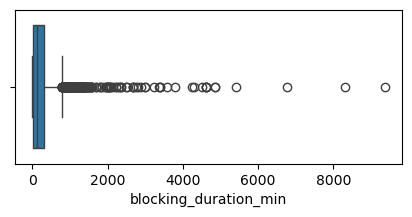

In [260]:
plt.figure(figsize=(5, 2))
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()

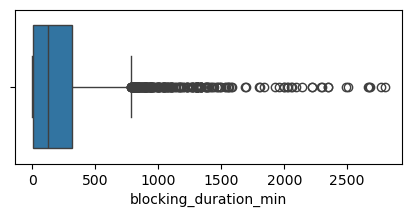

In [261]:
def iqr_outliers(series, lower_k, upper_k):
    Q1 = series.quantile(0.15)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - lower_k * IQR
    upper = Q3 + upper_k * IQR
    return lower, upper

lowerkWh, upperkWh = iqr_outliers(
    data_reg["kWhDelivered"], 
    lower_k=1.5, upper_k=5.0
    )

lowerc, upperc = iqr_outliers(
    data_reg["charging_duration_min"], 
    lower_k=1.5, upper_k=6.0
    )

lowerb, upperb = iqr_outliers(
    data_reg["blocking_duration_min"], 
    lower_k=1.5, upper_k=8.0
    )

data_reg = data_reg[
    (data_reg["kWhDelivered"] >= lowerkWh) &
    (data_reg["kWhDelivered"] <= upperkWh) &
    (data_reg["charging_duration_min"] >= lowerc) &
    (data_reg["charging_duration_min"] <= upperc) &
    (data_reg["blocking_duration_min"] >= lowerb) &
    (data_reg["blocking_duration_min"] <= upperb)
]
plt.figure(figsize=(5, 2))
sns.boxplot(x=data_reg["blocking_duration_min"])
plt.show()

#data_reg.info()


In [262]:
data_reg["kWhrequest_difference"] = data_reg["kWhRequested"] - data_reg["kWhDelivered"]
data_reg["kWhrequest_ratio"] = data_reg["kWhDelivered"]/(data_reg["kWhRequested"]+1)
print(data_reg["kWhrequest_difference"].min())
print(data_reg["kWhrequest_difference"].max())

-46.281
213.686


## Create User Dataframe


In [263]:
user_df = (
    data_reg
    .groupby("userID")
    .agg(
        n_sessions=("sessionID", "count"),

        first_session=("connectionTime", "min"),
        last_session=("connectionTime", "max"),
        
        avg_charging_time=("charging_duration_min", "mean"),
        avg_blocking_time=("blocking_duration_min", "mean"),
        blocking_ratio=("blocking_ratio", "mean"),

        weekday_ratio=("is_weekday", "mean"),
        avg_connection_hour_sin=("con_hour_sin", "mean"),
        avg_connection_hour_cos=("con_hour_cos", "mean"),
            
        site_one_ratio=("siteOne", "mean"),

        avg_kWh=("kWhDelivered", "mean"),       
        avg_wh_per_mile=("WhPerMile", "mean"),
        avg_minutes_available=("minutesAvailable", "mean"),
        avg_kWhRequest_ratio=("kWhrequest_ratio", "mean")
    )
    .reset_index()
)

We build further features that are possible key indicator variables of user behavior.

In [264]:
user_df["blocking_ratio"] = (
    user_df["avg_blocking_time"] /
    (user_df["avg_charging_time"] + user_df["avg_blocking_time"])
)

observation_start = data_reg['connectionTime'].min()
observation_end = data_reg["connectionTime"].max()
observation_span_weeks = (observation_end - observation_start).total_seconds()/(60*60*24*7)

user_df["active_weeks"] = (user_df["last_session"]-user_df["first_session"]).dt.total_seconds()/(60*60*24*7) + 1
user_df["active_weeks_ratio"] = user_df["active_weeks"] / observation_span_weeks
user_df["sessions_per_week"] = user_df["n_sessions"] / user_df["active_weeks"]

user_df["is_single_user"] = user_df["n_sessions"] == 1


user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 888 entries, 0 to 887
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype                              
---  ------                   --------------  -----                              
 0   userID                   888 non-null    float64                            
 1   n_sessions               888 non-null    int64                              
 2   first_session            888 non-null    datetime64[ns, America/Los_Angeles]
 3   last_session             888 non-null    datetime64[ns, America/Los_Angeles]
 4   avg_charging_time        888 non-null    float64                            
 5   avg_blocking_time        888 non-null    float64                            
 6   blocking_ratio           888 non-null    float64                            
 7   weekday_ratio            888 non-null    float64                            
 8   avg_connection_hour_sin  888 non-null    float64                      

## Feature selection and scaling

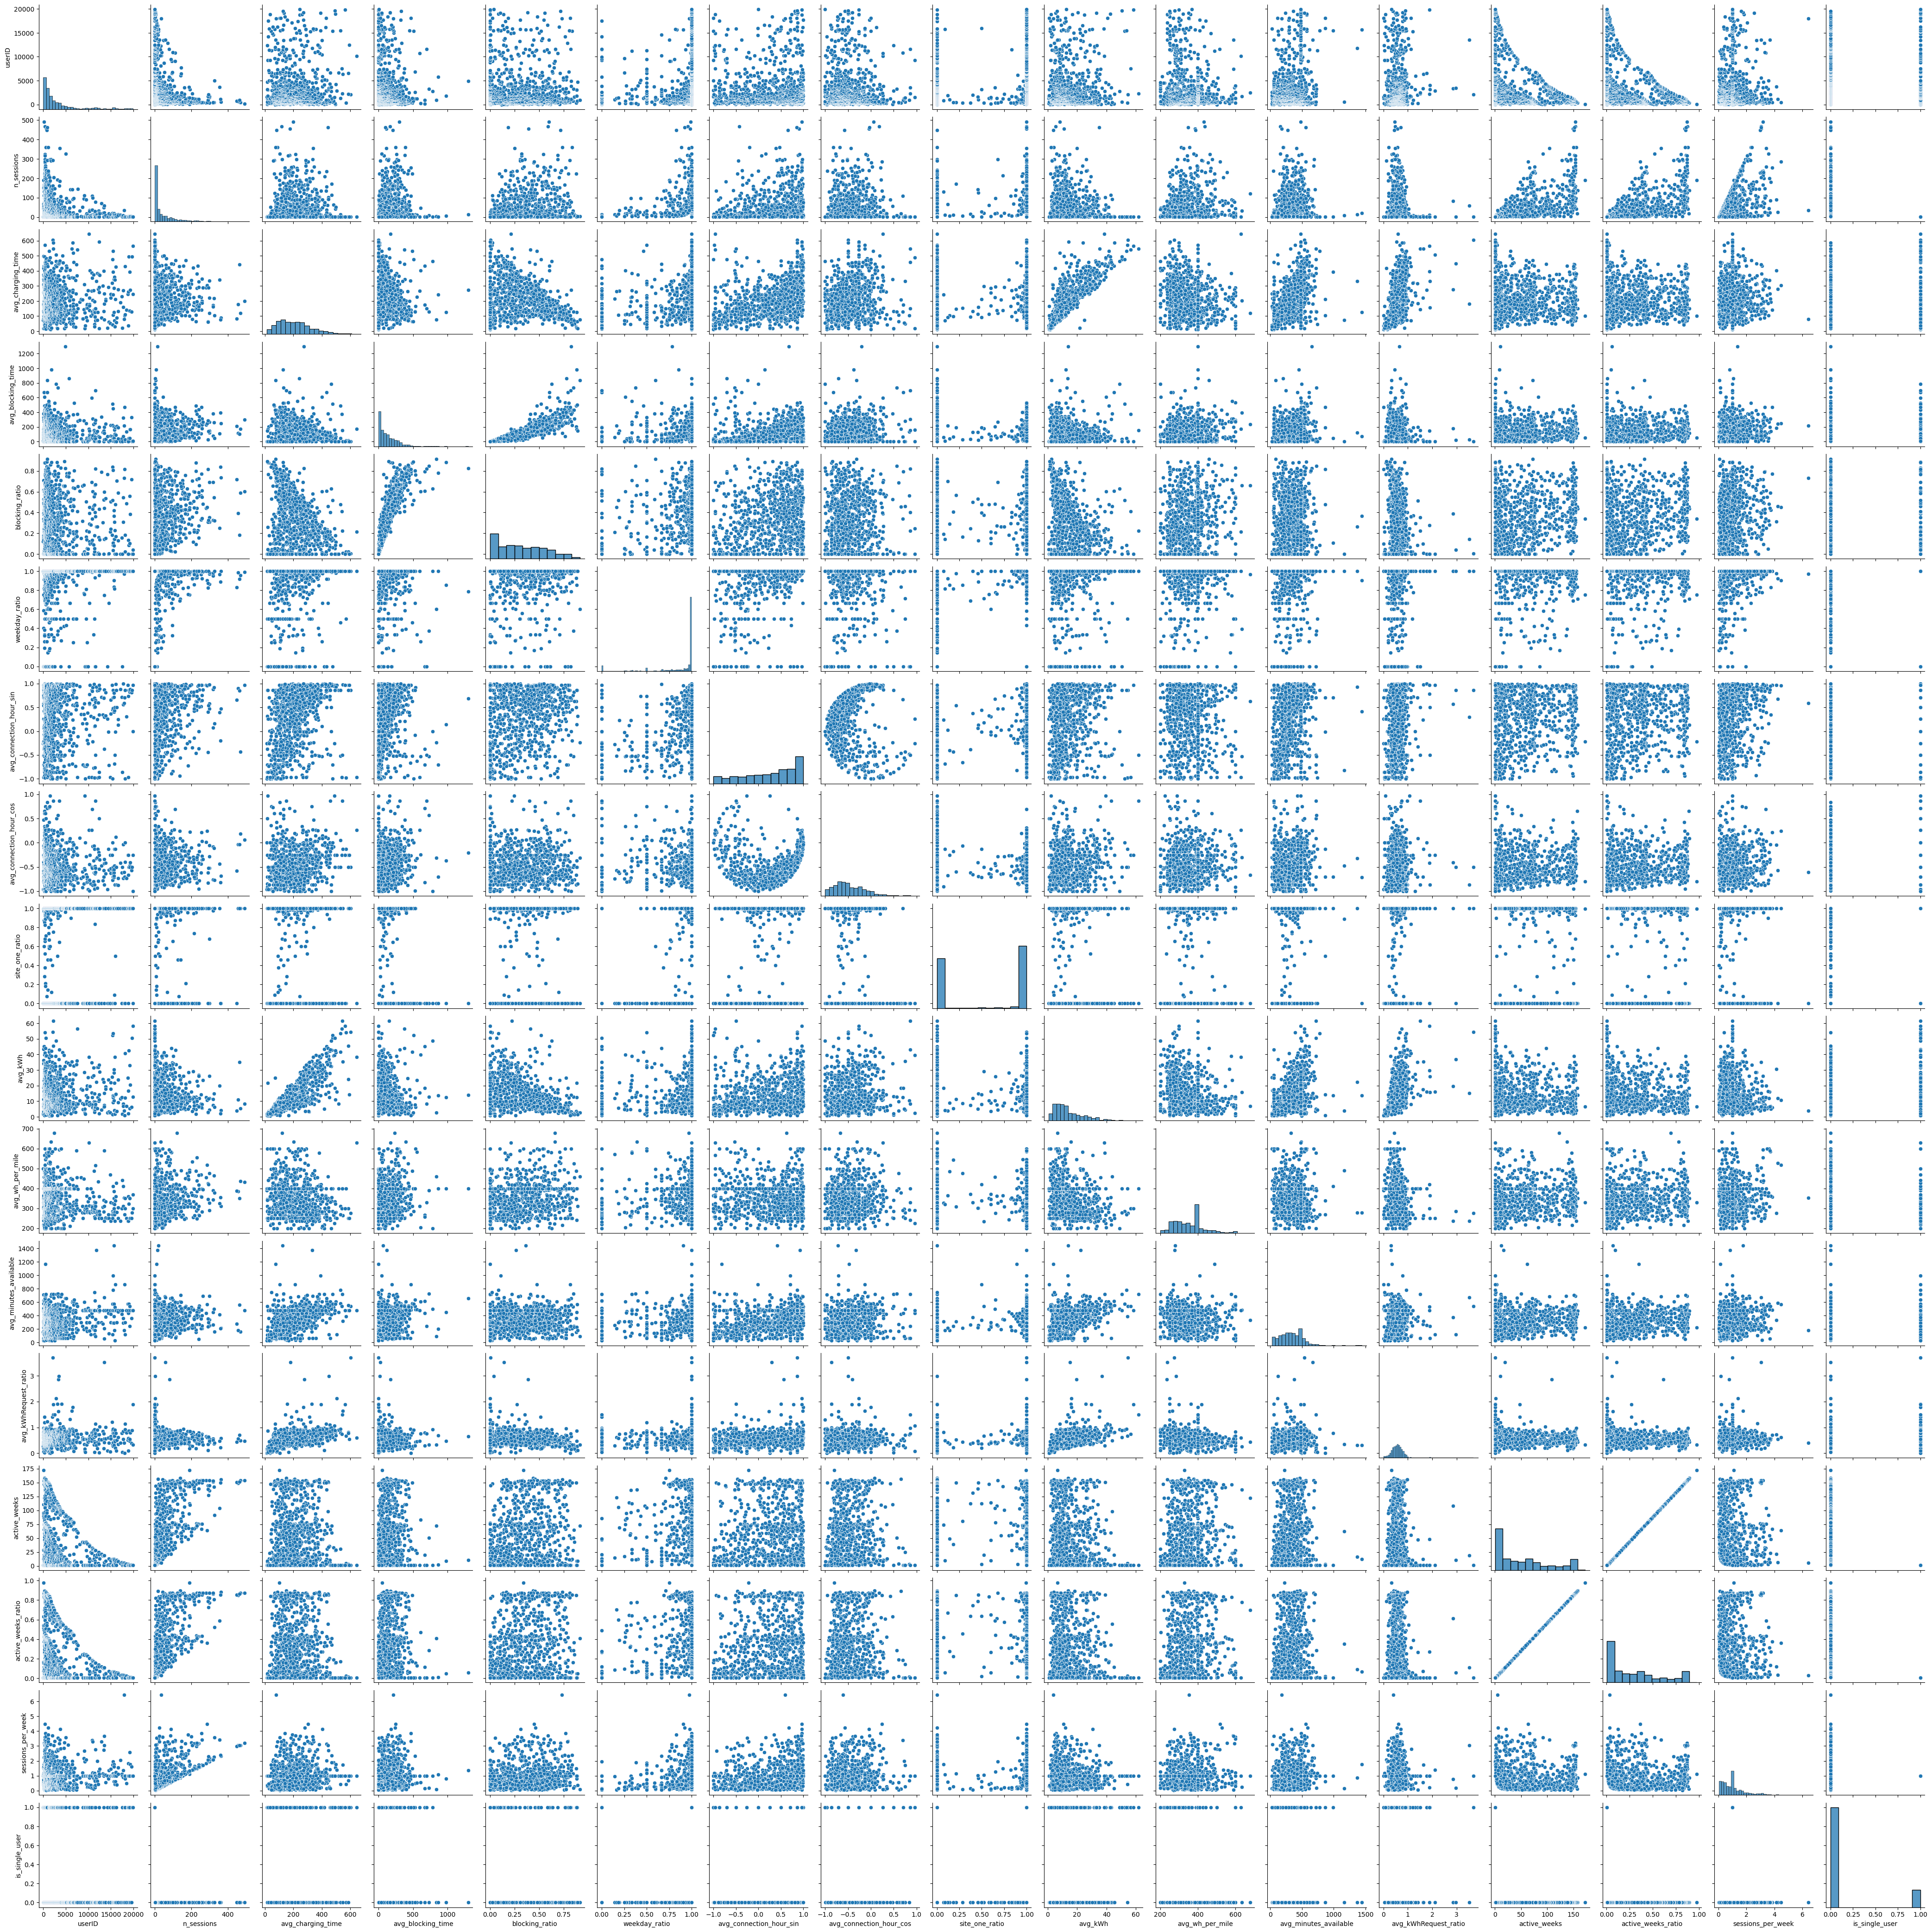

In [265]:
sns.pairplot(user_df)
plt.show()

In [287]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import dendrogram
%matplotlib inline

### Feature selection

Prior to the feature reduction process, technical and intermediate variables that were only required for feature construction were removed. These include *userID*, *n_sessions*, *first_session*, *last_session*, and *active_weeks*, as they do not represent independent behavioral characteristics and are either identifiers or redundant with derived features.


In [281]:
# dropping avg wh per mile and avg kWh, because it doesnt seem to have any relevance
X = user_df.drop(["userID","n_sessions","first_session", "last_session", "active_weeks"], axis=1)
X

,avg_charging_time,avg_blocking_time,blocking_ratio,weekday_ratio,avg_connection_hour_sin,avg_connection_hour_cos,site_one_ratio,avg_kWh,avg_wh_per_mile,avg_minutes_available,avg_kWhRequest_ratio,active_weeks_ratio,sessions_per_week,is_single_user
0,74.000000,10.000000,0.119048,1.0,-2.588190e-01,-0.965926,0.0,1.659000,500.000000,150.000000,0.276500,0.005679,1.000000,True
1,18.000000,0.000000,0.000000,0.0,-7.071068e-01,-0.707107,0.0,1.471000,346.000000,30.000000,0.185732,0.005679,1.000000,True
2,257.052632,129.947368,0.335781,1.0,5.793294e-01,-0.636510,0.0,18.748033,352.631579,461.578947,0.586084,0.511305,0.633093,False
3,419.000000,78.000000,0.156942,0.0,7.071068e-01,-0.707107,0.0,43.266000,217.000000,469.000000,0.974459,0.005679,1.000000,True
4,129.000000,84.000000,0.394366,0.0,-9.659258e-01,-0.258819,0.0,8.069000,250.000000,134.000000,0.436162,0.005679,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,272.333333,168.666667,0.382464,1.0,8.796528e-01,-0.408248,1.0,20.585333,251.000000,480.000000,0.788710,0.009662,1.763262,False
884,129.000000,332.000000,0.720174,1.0,8.130525e-01,-0.569036,1.0,6.256000,250.000000,360.000000,0.387244,0.010515,1.620210,False
885,494.000000,0.000000,0.000000,1.0,8.660254e-01,-0.500000,1.0,50.536000,278.000000,480.000000,0.892862,0.005679,1.000000,True
886,565.000000,0.000000,0.000000,1.0,9.659258e-01,-0.258819,0.0,58.354000,300.000000,480.000000,1.882387,0.005679,1.000000,True


To minimize the curse of dimensionality and improve cluster stability, we further reduce the remaining feature set by systematically removing redundant and low-informative variables.

- **Activity features**: The binary feature *is_single_user* does not provide additional information beyond the continuous activity measures *sessions_per_week* and *active_weeks_ratio*, as single-session users are uniquely identifiable through these variables. Therefore, *is_single_user* is removed.

- **charging and blocking behavior**: Charging duration and blocking behavior capture essential aspects of user interaction with the charging infrastructure. While *avg_blocking_time* provides absolute information, it is strongly influenced by session length. We therefore replace it with the dimensionless *blocking_ratio*, which captures user behavior more directly. The feature *avg_kWh* is highly correlated with *avg_charging_time*, resulting in limited additional information for clustering. We evaluated an alternative *kWhRequest_ratio* to represent the discrepancy between user expectations and actual charging behavior; however, empirical tests showed no substantial improvement in cluster separation. Consequently, this feature was excluded to maintain a compact and interpretable feature space.

- **temporal behavior**: The features *weekday_ratio*, *avg_connection_hour_sin*, and *avg_connection_hour_cos* encode complementary temporal usage patterns, but the test results showed, that the connection hour has little variation across cluster and extracting it produces much better silhouette scores. Therefore only the weekday ratio is retained.

- **Location Context**: Since charging behavior differs between private and public locations, the feature *site_one_ratio* provides relevant contextual information and is kept.

- **Additional User Characteristics**: The features *avg_wh_per_mile* and *avg_minutes_available* were evaluated empirically. Both showed limited variation across clusters, and their inclusion consistently reduced the silhouette score. As they did not contribute meaningfully to cluster differentiation, they were removed.

In [282]:
X = X.drop(["is_single_user","avg_blocking_time","avg_kWh","avg_kWhRequest_ratio", "avg_wh_per_mile", "avg_minutes_available", "avg_connection_hour_sin","avg_connection_hour_cos"], axis=1)
X

,avg_charging_time,blocking_ratio,weekday_ratio,site_one_ratio,active_weeks_ratio,sessions_per_week
0,74.000000,0.119048,1.0,0.0,0.005679,1.000000
1,18.000000,0.000000,0.0,0.0,0.005679,1.000000
2,257.052632,0.335781,1.0,0.0,0.511305,0.633093
3,419.000000,0.156942,0.0,0.0,0.005679,1.000000
4,129.000000,0.394366,0.0,0.0,0.005679,1.000000
...,...,...,...,...,...,...
883,272.333333,0.382464,1.0,1.0,0.009662,1.763262
884,129.000000,0.720174,1.0,1.0,0.010515,1.620210
885,494.000000,0.000000,1.0,1.0,0.005679,1.000000
886,565.000000,0.000000,1.0,0.0,0.005679,1.000000


### Scaling

Since extreme outliers were removed prior to clustering, the remaining feature distributions are sufficiently well-behaved. Therefore, StandardScaler is preferred over RobustScaler to preserve relative distances between observations.

In [283]:
use_robust = False
if (use_robust):
    scaler = RobustScaler()
else: scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Clustering

### K-Means CLustering

In [300]:
kclusters = []
klabels = pd.DataFrame()
ksil_scores = []
klosses = []

for k in range(2, 16):
    cluster = str(k)
    kclusters.append(k)
    kmodel = KMeans(n_clusters=k, random_state=42)
    label = kmodel.fit_predict(X_scaled)
    klabels[cluster] = label
    ksil_scores.append(silhouette_score(X_scaled, klabels[cluster]))
    klosses.append(kmodel.inertia_)

c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Larissa\anaconda3\envs\AA_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

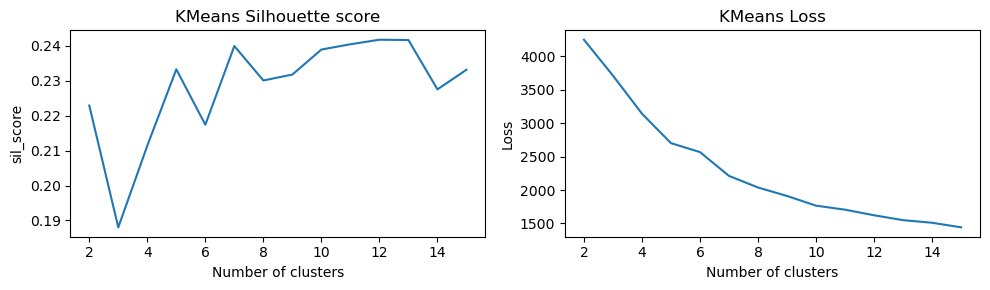

In [294]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(kclusters, ksil_scores)
axes[0].set_ylabel("sil_score")
axes[0].set_xlabel("Number of clusters")
axes[0].set_title("KMeans Silhouette score")

axes[1].plot(kclusters, klosses)
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Number of clusters")
axes[1].set_title("KMeans Loss")

plt.tight_layout()
plt.show()

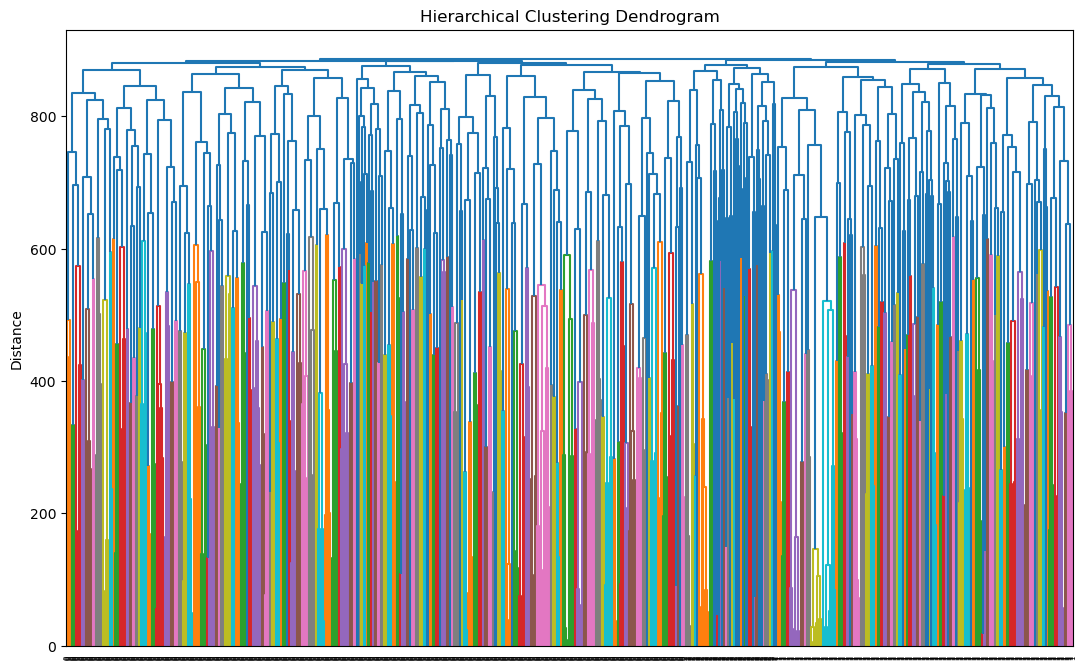

In [ ]:
aclusters = []
alabels = pd.DataFrame()
asil_scores = []
alosses = []

def plot_dendrogram(model, **kwargs):

    children = model.children_
    distance = np.arange(children.shape[0])

    no_of_observations = np.arange(2, children.shape[0]+2)
    linkage_matrix = np.column_stack([children, distance, no_of_observations]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

agglo = AgglomerativeClustering(n_clusters=3) 
y_pred_agglo = agglo.fit_predict(X_scaled)

plt.figure(figsize=(13,8))
plt.title('Hierarchical Clustering Dendrogram')
plot_dendrogram(agglo, labels=agglo.labels_)
plt.ylabel("Distance")
plt.show()

for k in range(2, 20):
    cluster = str(k)
    aclusters.append(k)
    amodel = AgglomerativeClustering(n_clusters=k)
    label = amodel.fit_predict(X_scaled)
    alabels[cluster] = label
    asil_scores.append(silhouette_score(X_scaled, label))

Text(0.5, 1.0, 'Agglomerative silhouette score')

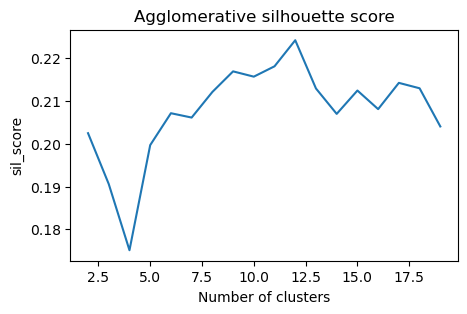

In [297]:
plt.figure(figsize=(5,3))
plt.plot(aclusters, asil_scores)
plt.ylabel("sil_score")
plt.xlabel("Number of clusters")
plt.title(f"Agglomerative silhouette score")

To do: decide on cluster method and number of clusters

In [298]:
#cluster 5 oder 7
kbest_cluster = str(5)
X["labels"] = klabels[kbest_cluster]
X

,avg_charging_time,blocking_ratio,weekday_ratio,site_one_ratio,active_weeks_ratio,sessions_per_week,labels
0,74.000000,0.119048,1.0,0.0,0.005679,1.000000,4
1,18.000000,0.000000,0.0,0.0,0.005679,1.000000,2
2,257.052632,0.335781,1.0,0.0,0.511305,0.633093,4
3,419.000000,0.156942,0.0,0.0,0.005679,1.000000,2
4,129.000000,0.394366,0.0,0.0,0.005679,1.000000,2
...,...,...,...,...,...,...,...
883,272.333333,0.382464,1.0,1.0,0.009662,1.763262,1
884,129.000000,0.720174,1.0,1.0,0.010515,1.620210,0
885,494.000000,0.000000,1.0,1.0,0.005679,1.000000,1
886,565.000000,0.000000,1.0,0.0,0.005679,1.000000,1


## Cluster analysis

In [275]:
"""
def sincos_to_hour(sin_val, cos_val):
    angle = np.arctan2(sin_val, cos_val)
    hour = (angle * 24 / (2 * np.pi)) % 24
    return hour
X["avg_connection_hour"] = sincos_to_hour(X["avg_connection_hour_sin"], X["avg_connection_hour_cos"])
X = X.drop(["avg_connection_hour_sin", "avg_connection_hour_cos"], axis=1)
"""

'\ndef sincos_to_hour(sin_val, cos_val):\n    angle = np.arctan2(sin_val, cos_val)\n    hour = (angle * 24 / (2 * np.pi)) % 24\n    return hour\nX["avg_connection_hour"] = sincos_to_hour(X["avg_connection_hour_sin"], X["avg_connection_hour_cos"])\nX = X.drop(["avg_connection_hour_sin", "avg_connection_hour_cos"], axis=1)\n'

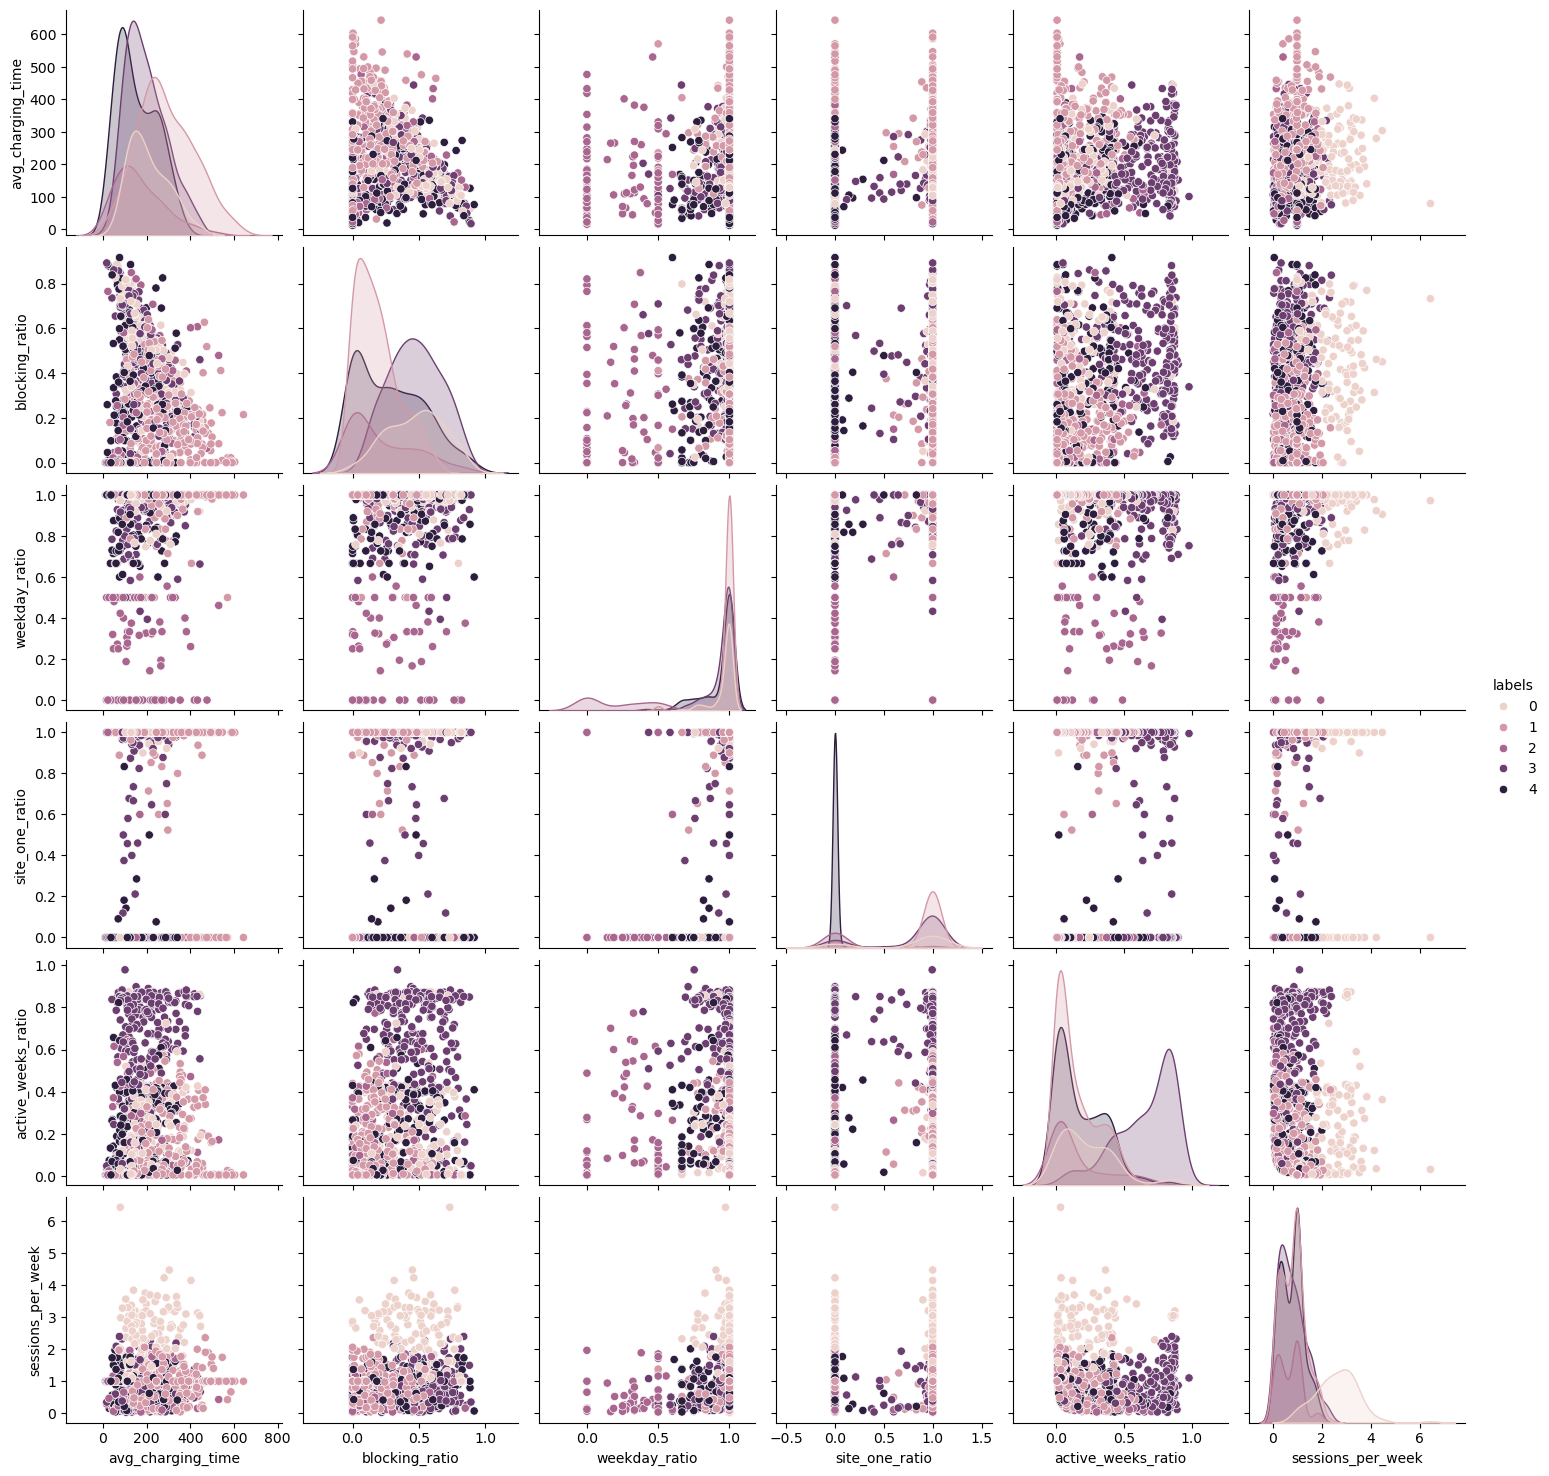

In [276]:
sns.pairplot(X, hue="labels")
plt.show()

In [301]:
X[X["labels"] == 0].describe()

,avg_charging_time,blocking_ratio,weekday_ratio,site_one_ratio,active_weeks_ratio,sessions_per_week,labels
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.0
mean,209.739462,0.470321,0.967289,0.753758,0.232323,2.615438,0.0
std,91.546246,0.211555,0.067150,0.429513,0.211008,0.863666,0.0
min,56.000000,0.000000,0.666667,0.000000,0.005679,1.000000,0.0
25%,133.166667,0.313479,0.971825,0.910937,0.059679,2.044258,0.0
50%,184.544444,0.497155,1.000000,1.000000,0.182557,2.672777,0.0
75%,278.731518,0.616020,1.000000,1.000000,0.378446,3.176330,0.0
max,447.663043,0.886525,1.000000,1.000000,0.874162,6.440820,0.0


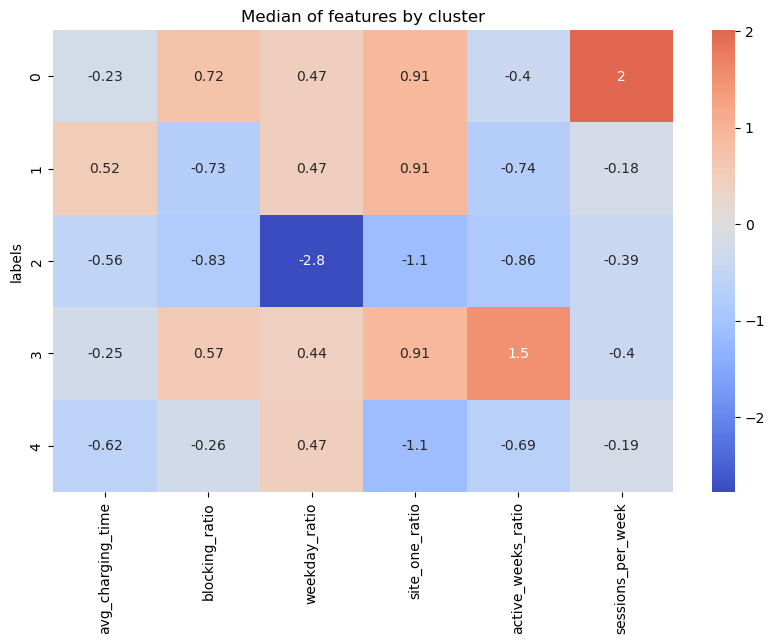

In [302]:
feature_cols = X.columns.drop("labels")

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=X.index
)

X_scaled_df["labels"] = X["labels"]
features = X_scaled_df.columns.drop("labels")
cluster_medians = X_scaled_df.groupby("labels")[features].median()

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Median of features by cluster")
plt.show()

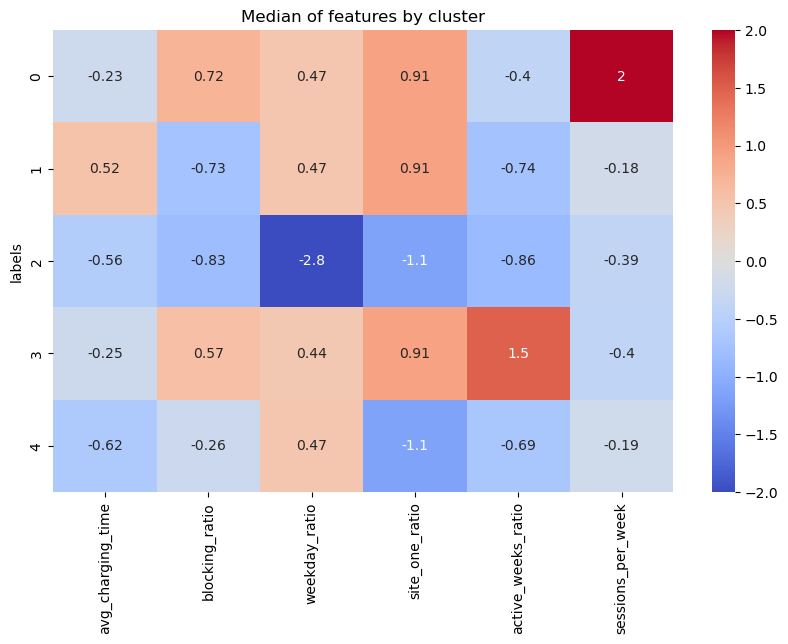

In [303]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_medians,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-2,
    vmax=2
)
plt.title("Median of features by cluster")
plt.show()

Agglomerative with 7 clusters:
- Cluster 0: charge very regularly and quik, efficient, early in the day - pendler, ideal user for infrastructure
- Cluster 1: charge mid often and a little longer, have the time and charge later the day - regular user who have chargingstation 1 close to the workplace or home, potentially blocking but planbar
- Cluster 2: all values relatively close to zero, charges at station 1 - average user with no strong pattern, good as reference group
- Cluster 3: average user who charges at station 2, has a little more time than cluster 2 users
- cluster 4: irregular weekend user who charge later of the day and have very long charging and blocking time - inefficient blockers, problematic, hard to calculate
- cluster 5: users who charge only on the weekwend, who are efficient and charge quickly
- cluster 6: user with short charging times who leave right after charging and charge irregulary - hobby driver, little routine



In [ ]:
X["labels"].value_counts().sort_index()

labels
0    102
1    172
2     77
3    123
4    156
5    185
6     73
Name: count, dtype: int64

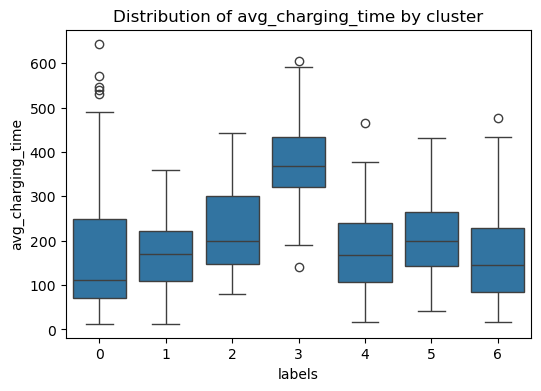

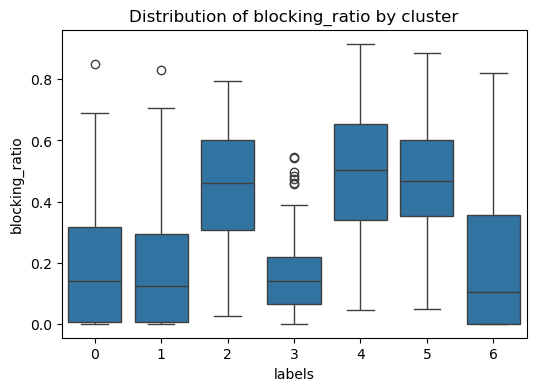

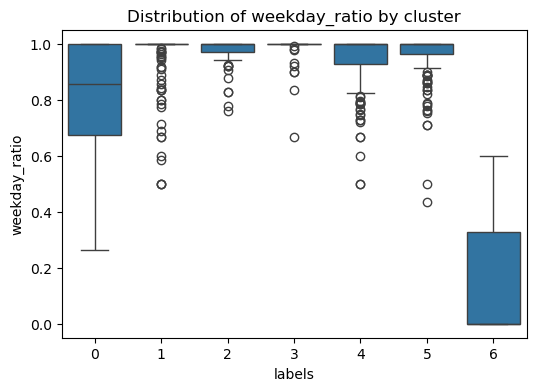

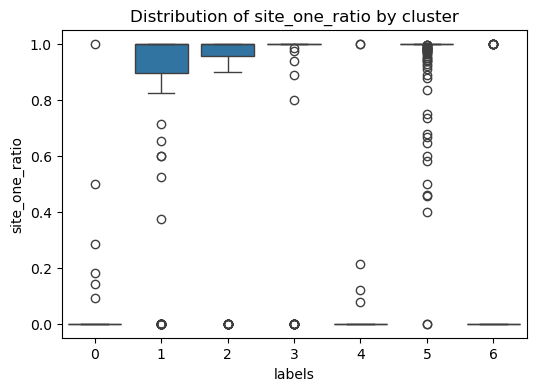

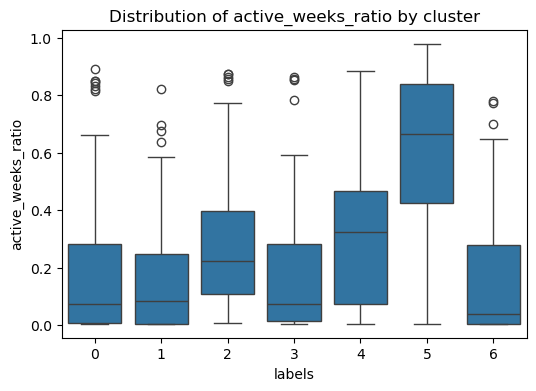

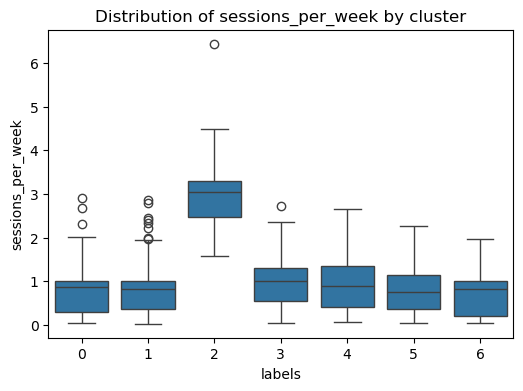

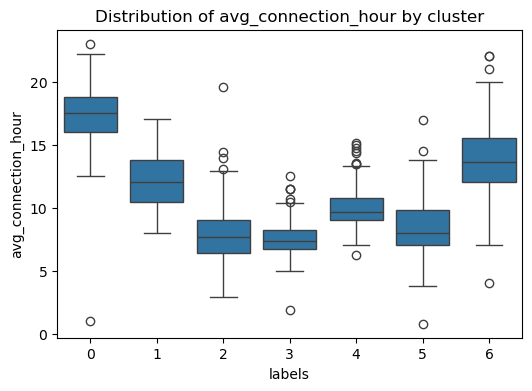

In [ ]:
for f in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="labels", y=f, data=X)
    plt.title(f"Distribution of {f} by cluster")
    plt.show()